<a href="https://colab.research.google.com/github/Shruthi10357/GEN-AI-Practice/blob/main/HuggingFace_Embeddings_Scratch_to_Intermediate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Embeddings using Hugging Face (Free models)**Level:** Scratch → Intermediate**Runs on:** Google Colab (Free CPU/GPU)### What you will learn1. What an embedding is (in simple words)2. Installing free, open Hugging Face libraries3. Generating embeddings with `sentence-transformers`4. Comparing text similarity using cosine similarity5. Visualizing embeddings in 2D6. Building a mini Semantic Search engine (intermediate project)> No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.

## 1. What is an Embedding?- An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text.- Similar sentences → similar (close) vectors.- Different sentences → far apart vectors.Example:- "I love dogs" and "I like puppies" → vectors will be **close**- "I love dogs" and "The stock market crashed" → vectors will be **far apart**We will use the `sentence-transformers` library, which uses free Hugging Face models.

### 2. Install Required LibrariesRun this once. `-q` keeps the output quiet (low token / clean output).

In [4]:
!pip install -q sentence-transformers scikit-learn matplotlib

### 3. Load a Free Hugging Face ModelWe are using **`all-MiniLM-L6-v2`** — a small, fast, completely free open-source model from Hugging Face.- Size: ~80MB- Great for learning and even production use- Output: 384-dimensional embedding vector per sentence

In [5]:
from sentence_transformers import SentenceTransformer# Load the free pre-trained model from Hugging Facemodel = SentenceTransformer('all-MiniLM-L6-v2')print("Model loaded successfully!")

### 4. Generate Your First Embedding

In [12]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the *meaning* of the sentence.

### 5. Generate Embeddings for Multiple Sentences

In [14]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


### 6. Measure Similarity Between SentencesWe use **Cosine Similarity** to check how close two embeddings are.- Score close to `1` → very similar meaning- Score close to `0` → unrelated meaning- Score close to `-1` → opposite meaning (rare with text)

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


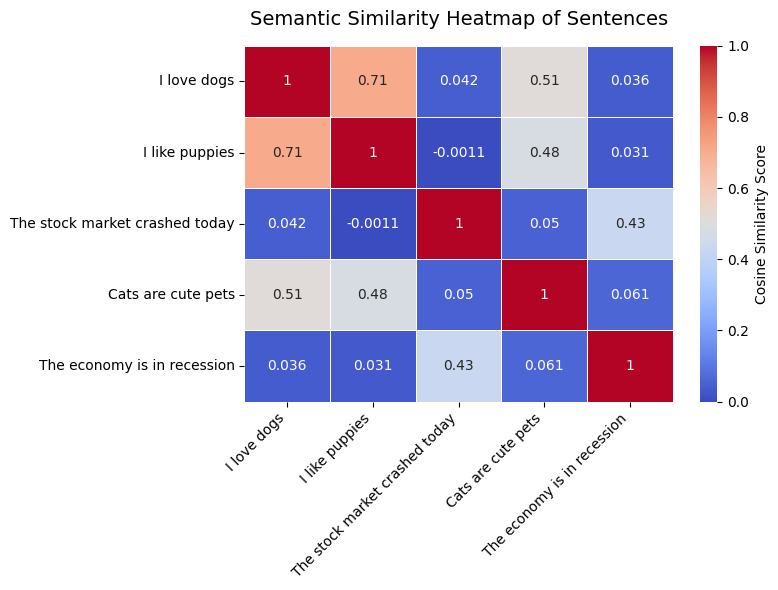

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a heatmap using seaborn
sns.heatmap(
    df,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Cosine Similarity Score"}
)

# Add titles and adjust labels
plt.title("Semantic Similarity Heatmap of Sentences", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

**Important Discussion Point:**Look at the similarity score between *"I love dogs"* and *"I like puppies"* — it should be high.Compare that to *"I love dogs"* vs *"The stock market crashed today"* — it should be low.This is the **core idea behind semantic search, chatbots, and recommendation systems**.

### 7. Visualize Embeddings in 2D (using PCA)Embeddings have 384 dimensions — we can't see that. So we reduce it to 2D just to *visualize* how sentences cluster.

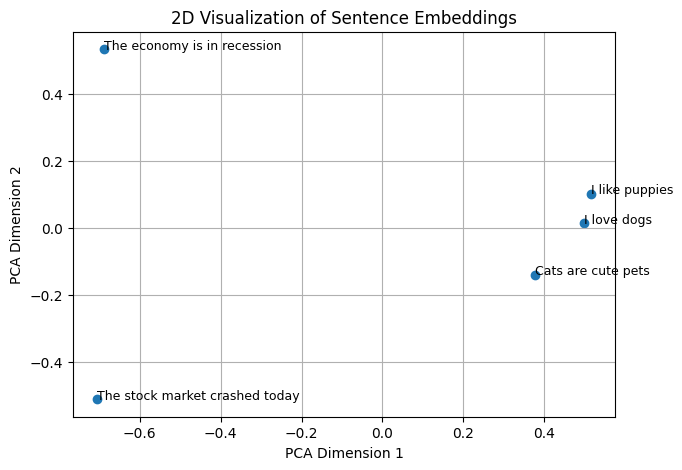

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])
for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear **closer together** in the plot, even though we never told the model to group them manually.

## 8. Intermediate Project: Mini Semantic Search Engine**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.

In [22]:
# Our small "document" databasedocuments = [    "Python is a popular programming language for AI.",    "The weather today is sunny and warm.",    "Machine learning models learn patterns from data.",    "I enjoy playing football on weekends.",    "Deep learning uses neural networks with many layers.",    "Paris is the capital city of France."]# Encode all documents oncedoc_embeddings = model.encode(documents)def semantic_search(query, top_k=2):    query_embedding = model.encode([query])    scores = cosine_similarity(query_embedding, doc_embeddings)[0]    # Rank documents by similarity score    ranked_idx = scores.argsort()[::-1][:top_k]    print(f"Query: {query}\n")    for idx in ranked_idx:        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")# Try itsemantic_search("Tell me about AI and neural networks")

In [23]:
# Try another querysemantic_search("What is the capital of France?")

### 9. Key Takeaways (Recap for Students)| Concept | Meaning ||---|---|| Embedding | Numeric vector representing meaning of text || Model used | `all-MiniLM-L6-v2` (free, open-source, Hugging Face) || Cosine Similarity | Measures how close two embeddings are || Semantic Search | Finding relevant text by meaning, not exact words || PCA | Used only to visualize high-dimension vectors in 2D |### 10. Practice Exercises (for students)1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.